# 附：Codes .{unnumbered}

本 Notebook 用于生成 `04_tobit_model_lec.ipynb` 中调用的图片和模拟数据。本 Notebook 仅用于生成讲义中的插图和模拟数据，主讲义不依赖这里的绘图细节。

运行后会生成两个文件夹：

- `./figs/`：保存讲义中的插图；
- `./data/`：保存模拟的企业研发投入数据 `tobit_rd_sim.csv`。

图片命名统一采用 `limit_dep_tobit_fig0#_xxx.png`，便于后续上传图床或在 Quarto book 中引用。

In [1]:
# ============================================================
# 0. 全局设置
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# 创建输出文件夹
os.makedirs("./figs", exist_ok=True)
os.makedirs("./data", exist_ok=True)

# 中文字体设置：
# Windows 通常可用 SimHei 或 Microsoft YaHei；
# macOS / Linux 若没有中文字体，图中中文可能无法正常显示，但不影响数据生成。
plt.rcParams["font.sans-serif"] = [
    "SimHei", "Microsoft YaHei", "Arial Unicode MS",
    "Noto Sans CJK SC", "DejaVu Sans"
]
plt.rcParams["axes.unicode_minus"] = False

# 统一绘图风格
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

# 固定随机种子，保证讲义图形可复现
rng = np.random.default_rng(20260428)

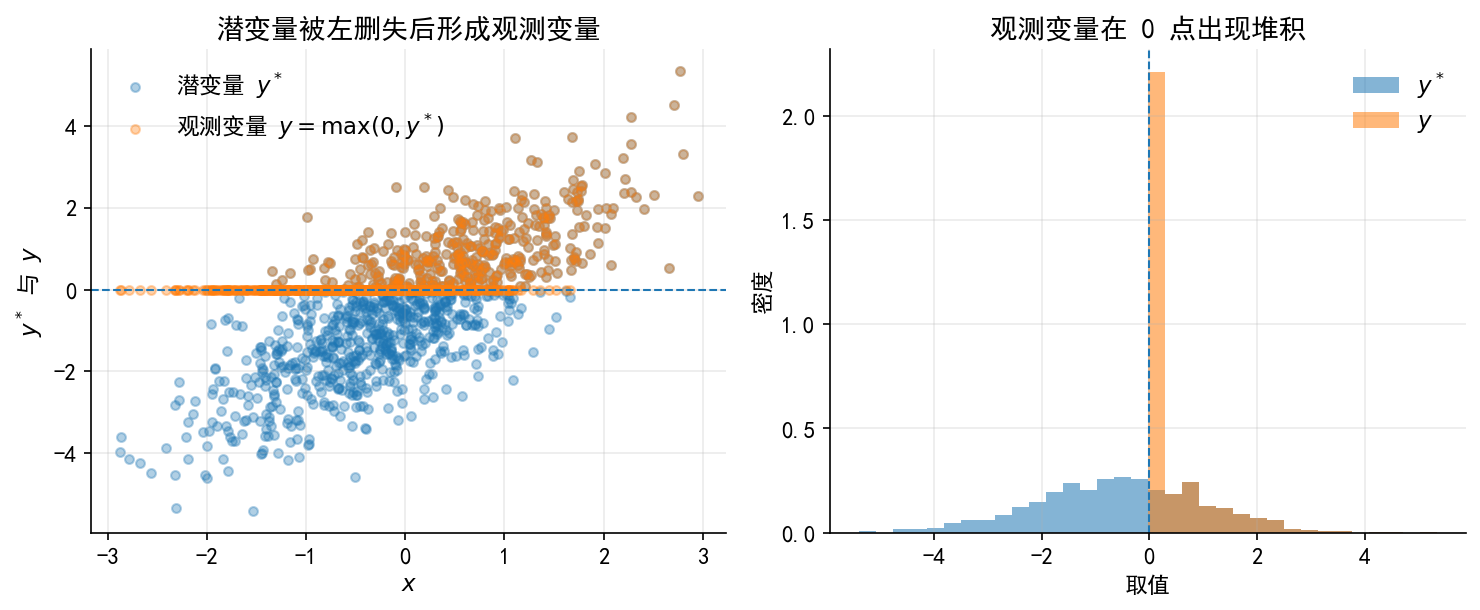

In [2]:
# ============================================================
# 1. 图 1：潜变量 y* 与观测变量 y 的关系
# ============================================================

n = 1000
x = rng.normal(0, 1, n)
u = rng.normal(0, 1, n)

# 潜变量：可理解为潜在净收益或潜在需求强度
y_latent = -0.5 + 1.2 * x + u

# 观测变量：当潜变量小于等于 0 时，只能观察到 y=0
y_obs = np.maximum(0, y_latent)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

# 左图：潜变量与观测变量
axes[0].scatter(x, y_latent, alpha=0.35, s=18, label=r"潜变量 $y^*$")
axes[0].scatter(x, y_obs, alpha=0.35, s=18, label=r"观测变量 $y=\max(0,y^*)$")
axes[0].axhline(0, linestyle="--", linewidth=1)
axes[0].set_xlabel(r"$x$")
axes[0].set_ylabel(r"$y^*$ 与 $y$")
axes[0].set_title("潜变量被左删失后形成观测变量")
axes[0].legend(frameon=False)

# 右图：分布对比
bins = np.linspace(min(y_latent.min(), y_obs.min()), max(y_latent.max(), y_obs.max()), 35)
axes[1].hist(y_latent, bins=bins, alpha=0.55, density=True, label=r"$y^*$")
axes[1].hist(y_obs, bins=bins, alpha=0.55, density=True, label=r"$y$")
axes[1].axvline(0, linestyle="--", linewidth=1)
axes[1].set_xlabel("取值")
axes[1].set_ylabel("密度")
axes[1].set_title("观测变量在 0 点出现堆积")
axes[1].legend(frameon=False)

fig.tight_layout()
fig.savefig("./figs/limit_dep_tobit_fig01_latent_observed.png", bbox_inches="tight")
plt.show()

In [3]:
# ============================================================
# 2. 生成企业研发投入强度模拟数据
# ============================================================

n = 2500

# 企业规模：可理解为标准化后的 log(总资产)
size = rng.normal(0, 1, n)

# 现金持有：为了简化，生成一个 0 到 1 之间的变量
cash = rng.beta(2.2, 5.0, n)

# 资产负债率：0 到 1 之间
lev = rng.beta(2.3, 3.0, n)

# 成长性和盈利能力：允许出现少量负值
growth = rng.normal(0.08, 0.22, n)
profit = rng.normal(0.05, 0.08, n)

# 随机扰动
sigma_true = 0.65
u = rng.normal(0, sigma_true, n)

# 潜在研发投入净收益或潜在研发投入强度
# 经济含义：
# - size 越大，研发项目吸收能力越强；
# - cash 越高，内部融资约束越弱；
# - lev 越高，债务约束越强；
# - growth 和 profit 越高，研发投入动机越强。
rd_latent = (
    -0.45
    + 0.35 * size
    + 1.20 * cash
    - 0.55 * lev
    + 0.75 * growth
    + 1.10 * profit
    + u
)

# 观测到的研发投入强度：左删失于 0
rd = np.maximum(0, rd_latent)

df = pd.DataFrame({
    "rd": rd,
    "rd_latent": rd_latent,
    "size": size,
    "cash": cash,
    "lev": lev,
    "growth": growth,
    "profit": profit
})

df.to_csv("./data/tobit_rd_sim.csv", index=False, encoding="utf-8-sig")

zero_share = (df["rd"] == 0).mean()
print(f"样本量: {len(df)}")
print(f"rd=0 的比例: {zero_share:.2%}")
df.head()

样本量: 2500
rd=0 的比例: 59.44%


,rd,rd_latent,size,cash,lev,growth,profit
0,0.175656,0.175656,0.873198,0.101710,0.580123,-0.119186,0.082959
1,0.000000,-1.894596,-1.347833,0.313840,0.316863,0.271610,0.076210
2,0.000000,-0.178420,0.148370,0.184377,0.658225,0.072306,-0.024811
3,0.000000,-0.670163,1.038085,0.262945,0.532851,-0.079404,0.008533
4,0.425271,0.425271,0.374561,0.341803,0.497331,0.344030,0.204810


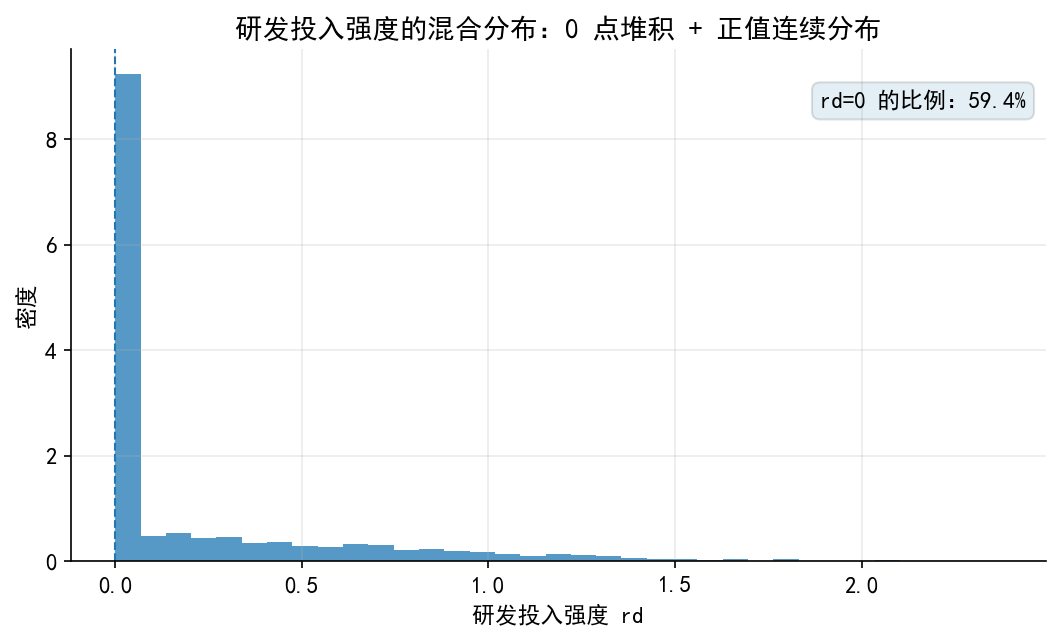

In [4]:
# ============================================================
# 3. 图 2：研发投入强度的分布
# ============================================================

fig, ax = plt.subplots(figsize=(7.2, 4.4))

ax.hist(df["rd"], bins=35, alpha=0.75, density=True)
ax.axvline(0, linestyle="--", linewidth=1)
ax.set_xlabel("研发投入强度 rd")
ax.set_ylabel("密度")
ax.set_title("研发投入强度的混合分布：0 点堆积 + 正值连续分布")

txt = f"rd=0 的比例：{zero_share:.1%}"
ax.text(0.98, 0.92, txt, transform=ax.transAxes, ha="right", va="top",
        bbox=dict(boxstyle="round,pad=0.35", alpha=0.12))

fig.tight_layout()
fig.savefig("./figs/limit_dep_tobit_fig02_rd_distribution.png", bbox_inches="tight")
plt.show()

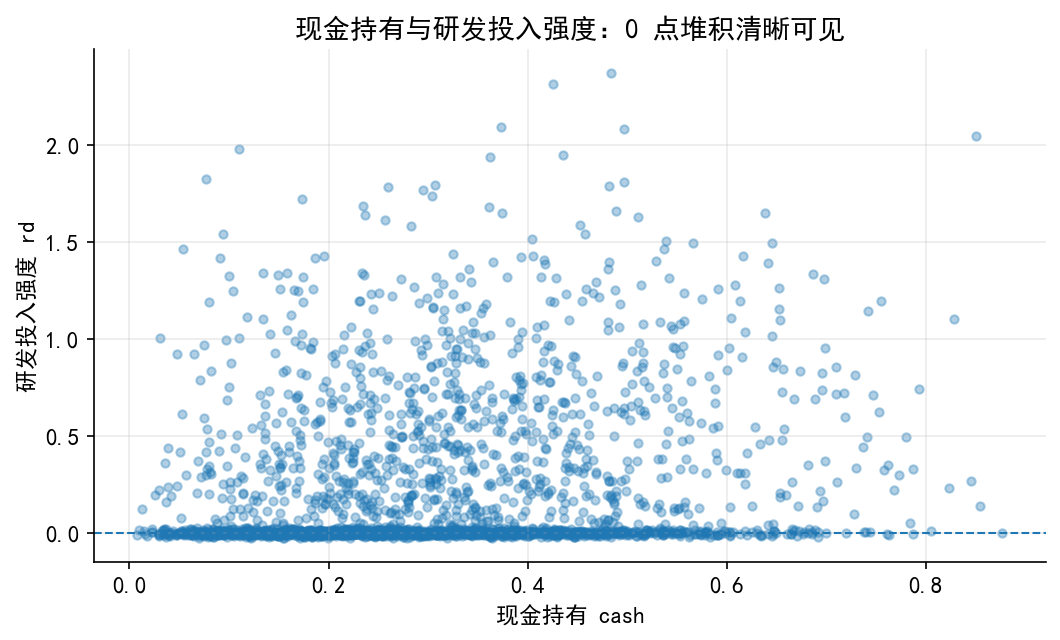

In [5]:
# ============================================================
# 4. 图 3：删失点附近的数据特征
# ============================================================

fig, ax = plt.subplots(figsize=(7.2, 4.4))

# 对 rd=0 的点做轻微纵向扰动，避免完全重叠
jitter = rng.normal(0, 0.01, len(df))
rd_jitter = df["rd"] + np.where(df["rd"] == 0, jitter, 0)

ax.scatter(df["cash"], rd_jitter, s=16, alpha=0.35)
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_xlabel("现金持有 cash")
ax.set_ylabel("研发投入强度 rd")
ax.set_title("现金持有与研发投入强度：0 点堆积清晰可见")

fig.tight_layout()
fig.savefig("./figs/limit_dep_tobit_fig03_censoring_pattern.png", bbox_inches="tight")
plt.show()

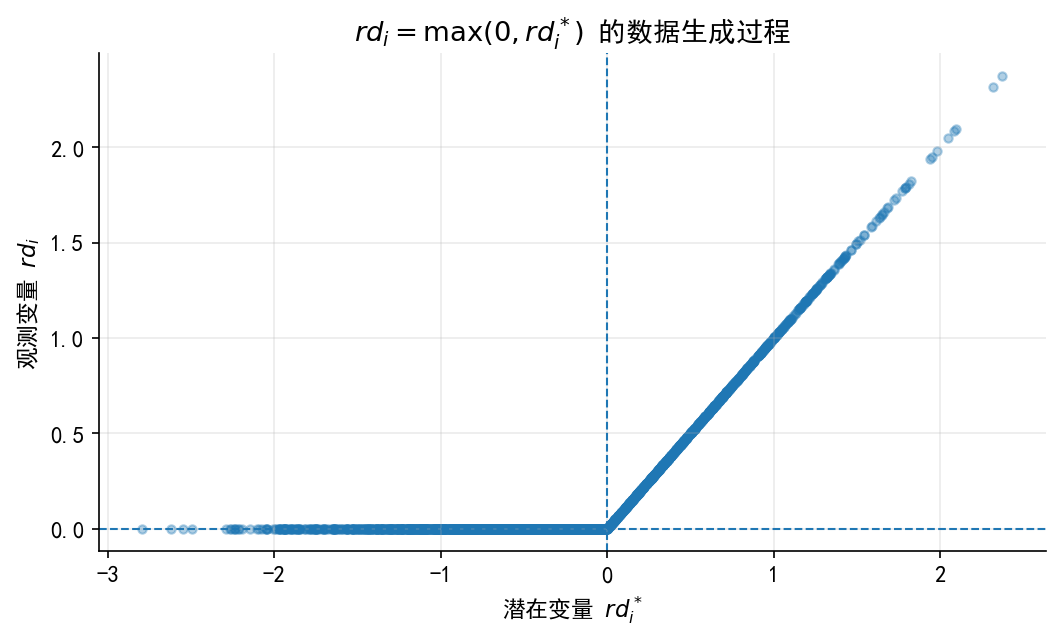

In [6]:
# ============================================================
# 5. 图 4：潜在研发投入强度与观测研发投入强度
# ============================================================

fig, ax = plt.subplots(figsize=(7.2, 4.4))

ax.scatter(df["rd_latent"], df["rd"], s=16, alpha=0.35)
ax.axvline(0, linestyle="--", linewidth=1)
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_xlabel(r"潜在变量 $rd_i^*$")
ax.set_ylabel(r"观测变量 $rd_i$")
ax.set_title(r"$rd_i=\max(0, rd_i^*)$ 的数据生成过程")

fig.tight_layout()
fig.savefig("./figs/limit_dep_tobit_fig04_latent_rd.png", bbox_inches="tight")
plt.show()

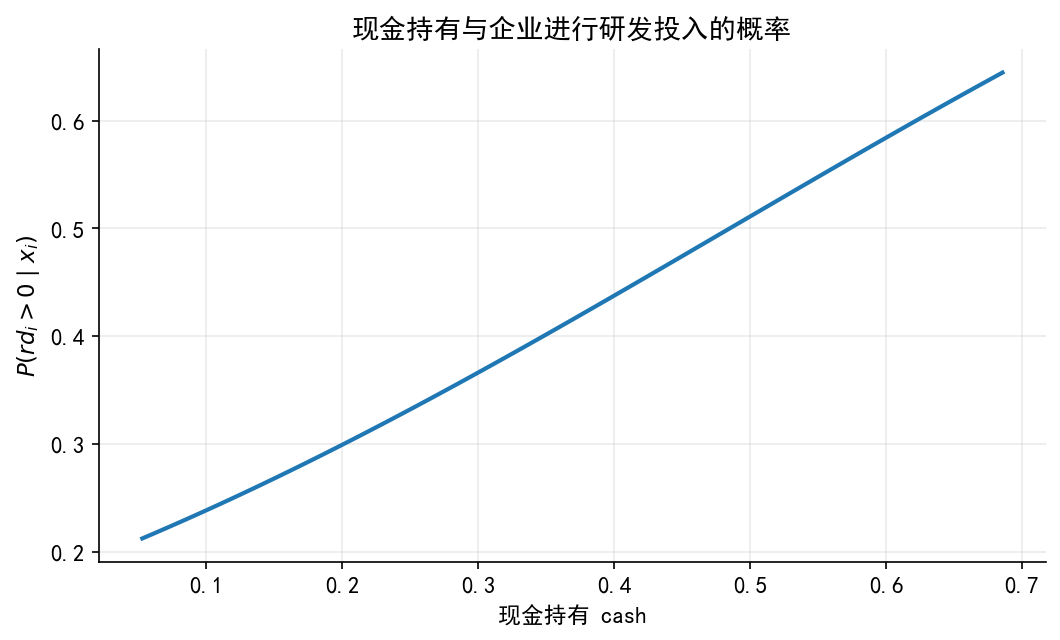

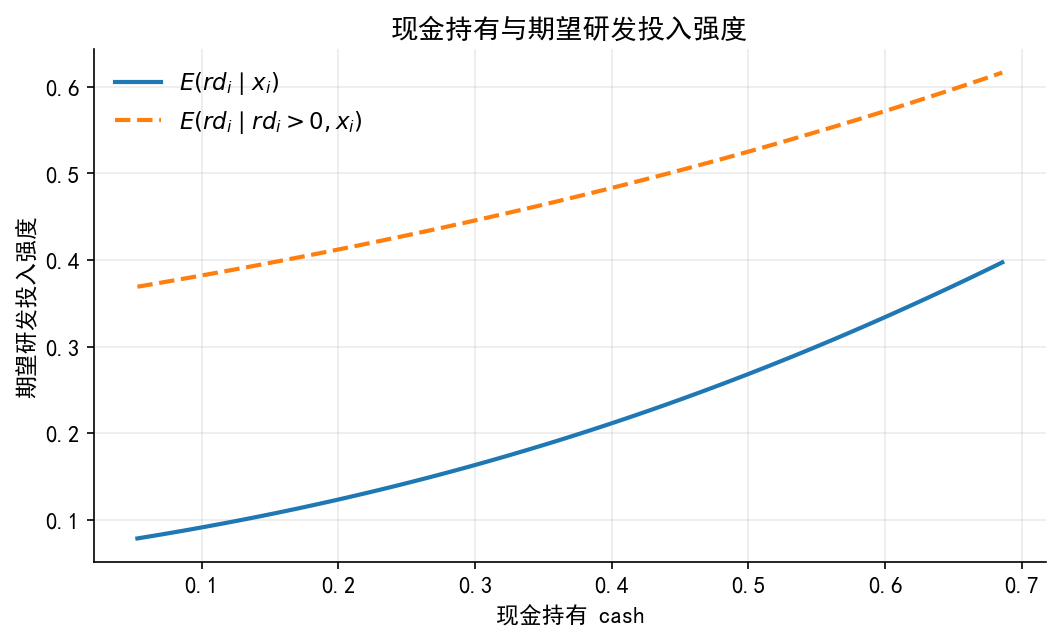

In [7]:
# ============================================================
# 6. 图 5 和图 6：现金持有变化时的概率与期望值
# ============================================================

cash_grid = np.linspace(df["cash"].quantile(0.02), df["cash"].quantile(0.98), 100)

# 其他变量固定在样本均值
size_bar = df["size"].mean()
lev_bar = df["lev"].mean()
growth_bar = df["growth"].mean()
profit_bar = df["profit"].mean()

mu_grid = (
    -0.45
    + 0.35 * size_bar
    + 1.20 * cash_grid
    - 0.55 * lev_bar
    + 0.75 * growth_bar
    + 1.10 * profit_bar
)

z_grid = mu_grid / sigma_true
prob_pos = norm.cdf(z_grid)
ey_obs = norm.cdf(z_grid) * mu_grid + sigma_true * norm.pdf(z_grid)
ey_pos = mu_grid + sigma_true * norm.pdf(z_grid) / np.clip(norm.cdf(z_grid), 1e-12, None)

# 图 5：P(rd>0 | x)
fig, ax = plt.subplots(figsize=(7.2, 4.4))
ax.plot(cash_grid, prob_pos, linewidth=2)
ax.set_xlabel("现金持有 cash")
ax.set_ylabel(r"$P(rd_i>0\mid x_i)$")
ax.set_title("现金持有与企业进行研发投入的概率")
fig.tight_layout()
fig.savefig("./figs/limit_dep_tobit_fig05_cash_prob.png", bbox_inches="tight")
plt.show()

# 图 6：E(rd | x) 和 E(rd | rd>0, x)
fig, ax = plt.subplots(figsize=(7.2, 4.4))
ax.plot(cash_grid, ey_obs, linewidth=2, label=r"$E(rd_i\mid x_i)$")
ax.plot(cash_grid, ey_pos, linewidth=2, linestyle="--", label=r"$E(rd_i\mid rd_i>0,x_i)$")
ax.set_xlabel("现金持有 cash")
ax.set_ylabel("期望研发投入强度")
ax.set_title("现金持有与期望研发投入强度")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig("./figs/limit_dep_tobit_fig06_cash_expected_rd.png", bbox_inches="tight")
plt.show()

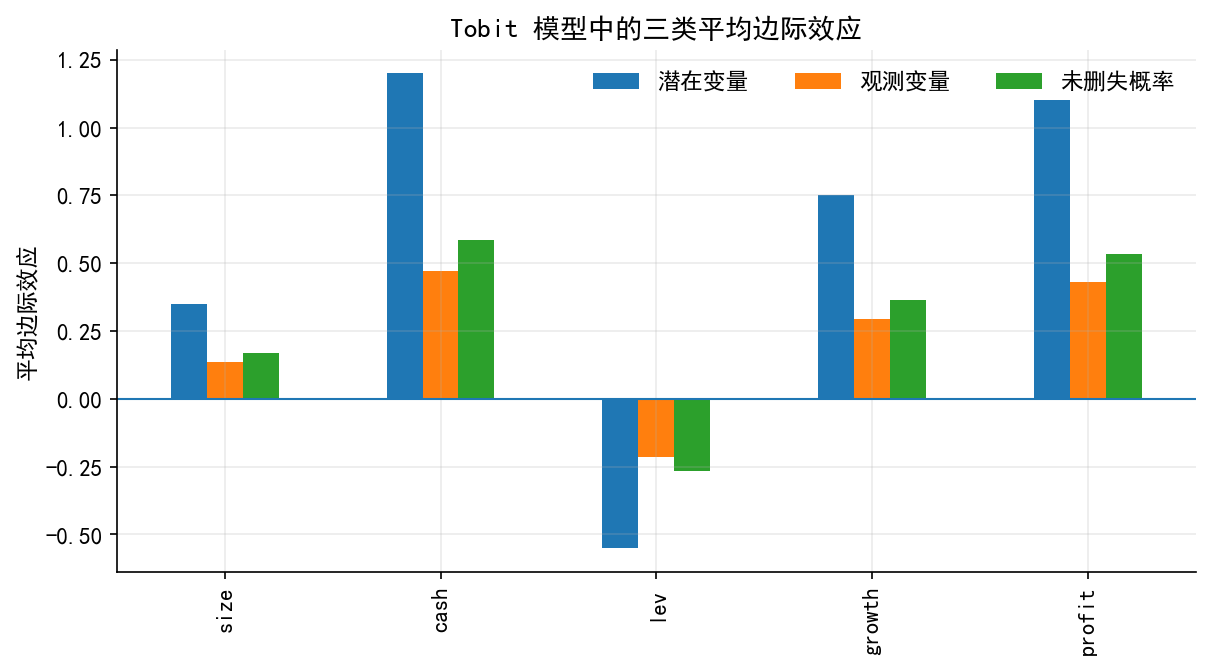

,潜在变量,观测变量,未删失概率
size,0.35,0.1374,0.1703
cash,1.20,0.4712,0.5837
lev,-0.55,-0.2160,-0.2675
growth,0.75,0.2945,0.3648
profit,1.10,0.4319,0.5351


In [8]:
# ============================================================
# 7. 图 7：三类平均边际效应对比
# ============================================================

X_true = df[["size", "cash", "lev", "growth", "profit"]].copy()
beta_true = pd.Series({
    "size": 0.35,
    "cash": 1.20,
    "lev": -0.55,
    "growth": 0.75,
    "profit": 1.10
})

mu = (
    -0.45
    + 0.35 * df["size"]
    + 1.20 * df["cash"]
    - 0.55 * df["lev"]
    + 0.75 * df["growth"]
    + 1.10 * df["profit"]
)
z = mu / sigma_true
Phi_bar = norm.cdf(z).mean()
phi_bar = norm.pdf(z).mean()

me = pd.DataFrame({
    "潜在变量": beta_true,
    "观测变量": Phi_bar * beta_true,
    "未删失概率": (phi_bar / sigma_true) * beta_true
})

fig, ax = plt.subplots(figsize=(8.2, 4.6))
me.plot(kind="bar", ax=ax)
ax.axhline(0, linewidth=1)
ax.set_ylabel("平均边际效应")
ax.set_title("Tobit 模型中的三类平均边际效应")
ax.legend(frameon=False, ncol=3)
fig.tight_layout()
fig.savefig("./figs/limit_dep_tobit_fig07_marginal_effects.png", bbox_inches="tight")
plt.show()

me.round(4)

# 运行完成检查

如果上述代码顺利运行，当前目录下应该出现：

- `./data/tobit_rd_sim.csv`
- `./figs/limit_dep_tobit_fig01_latent_observed.png`
- `./figs/limit_dep_tobit_fig02_rd_distribution.png`
- `./figs/limit_dep_tobit_fig03_censoring_pattern.png`
- `./figs/limit_dep_tobit_fig04_latent_rd.png`
- `./figs/limit_dep_tobit_fig05_cash_prob.png`
- `./figs/limit_dep_tobit_fig06_cash_expected_rd.png`
- `./figs/limit_dep_tobit_fig07_marginal_effects.png`

生成上述文件后，即可运行 Tobit 模型讲义主 Notebook。